# Breast Cancer Prediction
Dataset: Wisconsin Diagnostic Breast Cancer (WDBC)  
Target: `diagnosis` (M=Malignant→1, B=Benign→0)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/breast_cancer.csv")
df['target'] = (df['diagnosis'] == 'M').astype(int)
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [2]:
print("Class balance:", df['target'].value_counts().to_dict())
print("Missing values:", df.isnull().sum().sum())
df[['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','symmetry_mean']].describe()

Class balance: {0: 357, 1: 212}
Missing values: 0


,radius_mean,texture_mean,perimeter_mean,area_mean,concavity_mean,symmetry_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.088799,0.181162
std,3.524049,4.301036,24.298981,351.914129,0.079720,0.027414
min,6.981000,9.710000,43.790000,143.500000,0.000000,0.106000
25%,11.700000,16.170000,75.170000,420.300000,0.029560,0.161900
50%,13.370000,18.840000,86.240000,551.100000,0.061540,0.179200
75%,15.780000,21.800000,104.100000,782.700000,0.130700,0.195700
max,28.110000,39.280000,188.500000,2501.000000,0.426800,0.304000


## 2 · EDA

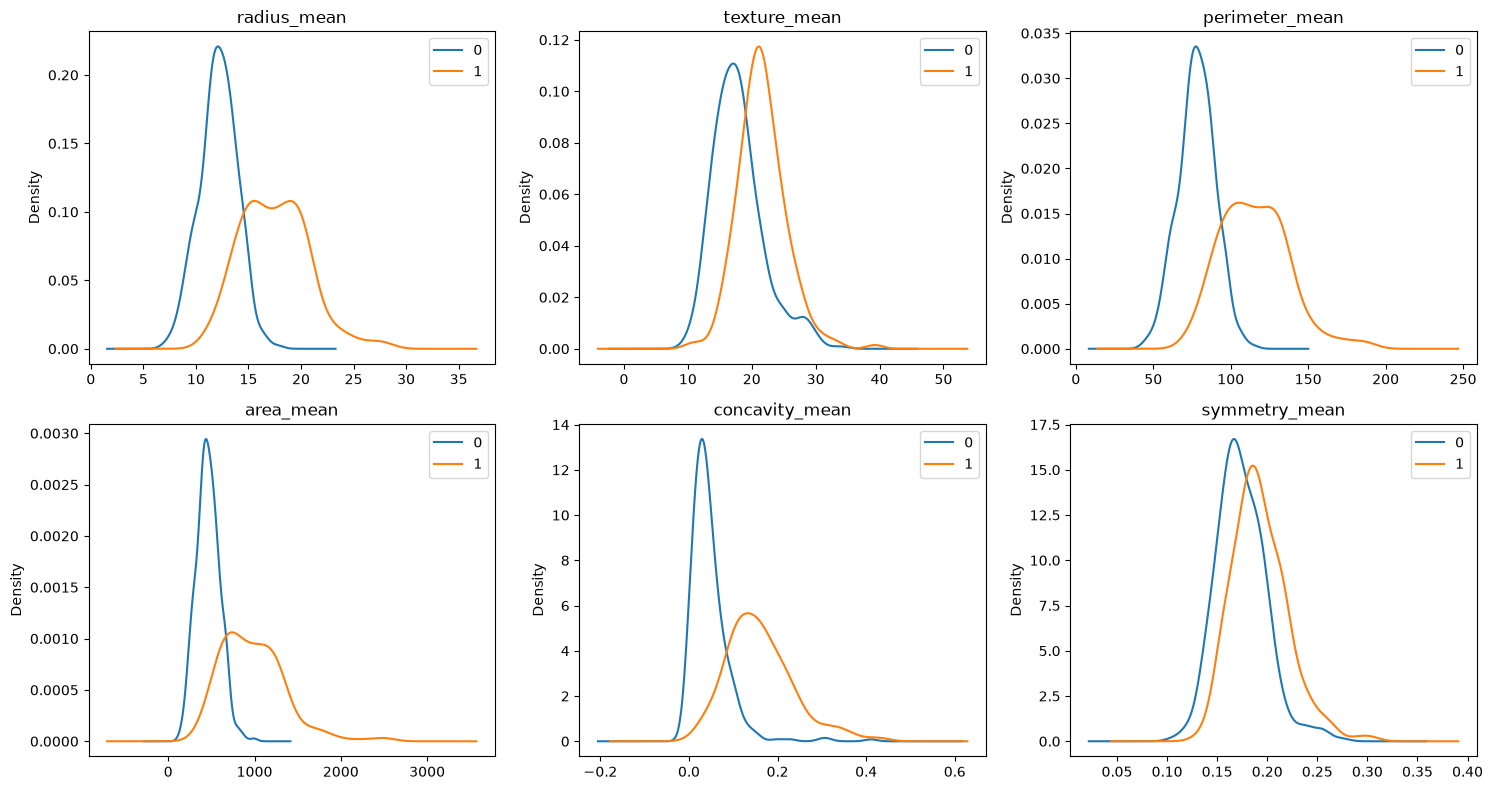

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','symmetry_mean']):
    ax = axes[i//3][i%3]
    df.groupby('target')[col].plot(kind='kde', ax=ax, legend=True, title=col)
plt.tight_layout(); plt.show()

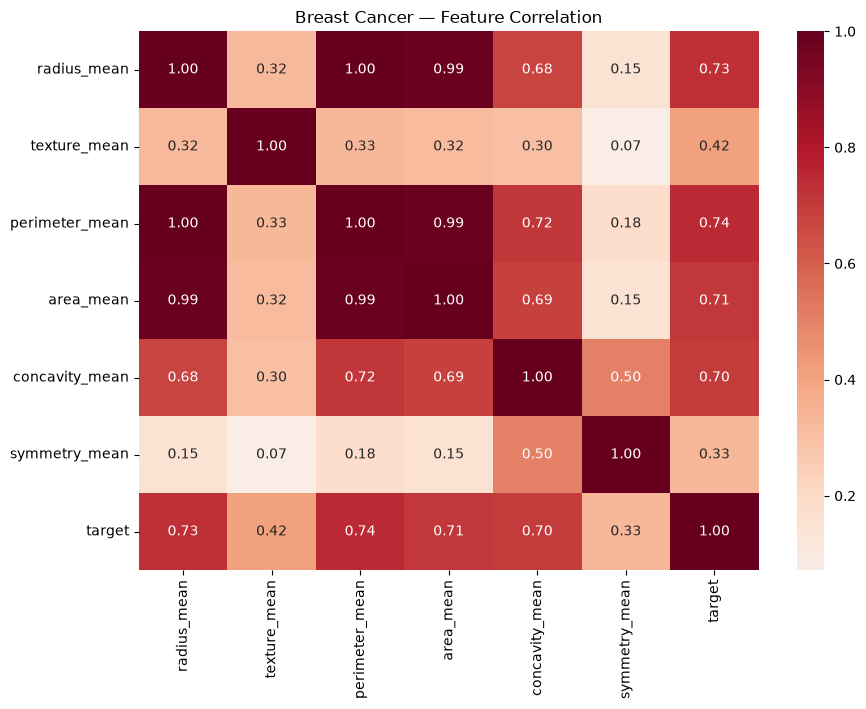

In [4]:
plt.figure(figsize=(10,7))
feat_cols = ['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','symmetry_mean','target']
sns.heatmap(df[feat_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Breast Cancer — Feature Correlation"); plt.show()

## 3 · Feature Engineering & Field Mapping


In [5]:
FEATURES = ['radius_mean','texture_mean','perimeter_mean','area_mean','concavity_mean','symmetry_mean']
X = df[FEATURES]
y = df['target']
print("Feature set shape:", X.shape)

Feature set shape: (569, 6)


## 4–5 · Preprocessing & Train/Test Split 

In [6]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('clf', clf)])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (455, 6), Test: (114, 6)


## 6 · Model Training & Comparison

In [9]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp = p.predict(X_test); ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy': round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall': round(recall_score(y_test,yp),4),
                     'f1': round(f1_score(y_test,yp),4),
                     'roc_auc': round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p
pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
XGBoost,0.9561,0.9512,0.9286,0.9398,0.9871
LogisticRegression,0.9211,0.9459,0.8333,0.8861,0.9831
RandomForest,0.9298,0.9474,0.8571,0.9000,0.9773


## 7 · Evaluation 

Best: XGBoost


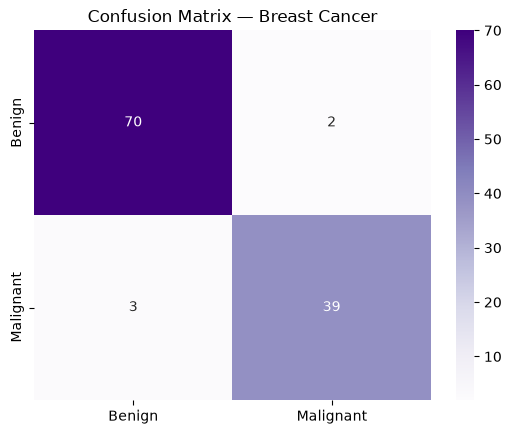

              precision    recall  f1-score   support

      Benign       0.96      0.97      0.97        72
   Malignant       0.95      0.93      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = pipes[best_name]; print(f"Best: {best_name}")
y_pred = best.predict(X_test); y_proba = best.predict_proba(X_test)[:,1]

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.title('Confusion Matrix — Breast Cancer'); plt.show()
print(classification_report(y_test, y_pred, target_names=['Benign','Malignant']))

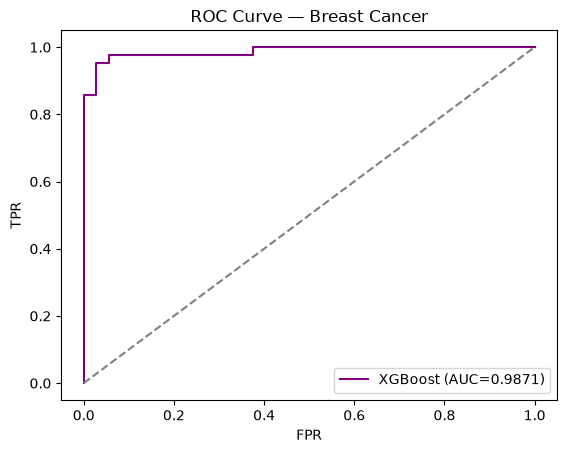

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})', color='purple')
plt.plot([0,1],[0,1],'--',color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Breast Cancer'); plt.legend(); plt.show()

## 8 · Save Model & Metrics

In [13]:
joblib.dump(best, '../models/breast_cancer_model.joblib')
metrics = {**results[best_name], 'model': best_name,
           'features': FEATURES, 'test_size': 0.2, 'random_state': 42}
with open('../metrics/breast_cancer_metrics.json','w') as f: json.dump(metrics,f,indent=2)
print(json.dumps(metrics, indent=2))

{
  "accuracy": 0.9561,
  "precision": 0.9512,
  "recall": 0.9286,
  "f1": 0.9398,
  "roc_auc": 0.9871,
  "model": "XGBoost",
  "features": [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "symmetry_mean"
  ],
  "test_size": 0.2,
  "random_state": 42
}
